In [1]:
from bluemath_tk.topo_bathy.profiles import reef

reef_profile = reef(
    dx=1,
    h0=15,
    Slope1=0.05,
    Slope2=0.05,
    Wreef=100,
    Wfore=100,
    bCrest=15,
    emsl=3,
)
print(f"Reef depth of length: {len(reef_profile)}")

Reef depth of length: 890


Text(0.5, 1.0, 'Reef Profile')

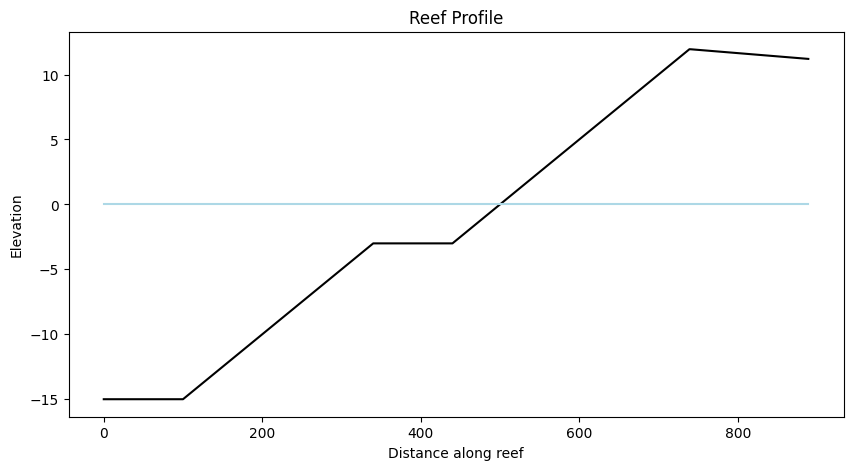

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
plt.plot(-reef_profile, c="k")
plt.plot(range(len(reef_profile)), np.repeat(0, len(reef_profile)), "lightblue")
plt.xlabel("Distance along reef")
plt.ylabel("Elevation")
plt.title("Reef Profile")

In [3]:
from bluemath_tk.wrappers._utils_wrappers import write_array_in_file
from bluemath_tk.wrappers.swash.swash_wrapper import SwashModelWrapper


class CustomSwashWrapper(SwashModelWrapper):
    """
    Custom SWASH wrapper that inherits from SwashModelWrapper.
    """

    def build_case(self, case_context: dict, case_dir: str) -> None:
        super().build_case(case_context=case_context, case_dir=case_dir)
        write_array_in_file(self.depth_array, f"{case_dir}/depth.bot")

In [4]:
metamodel_parameters = {
    "Hs": [1.0, 2.0, 3.0],
    "Hs_L0": [0.01],
}
metamodel_parameters

{'Hs': [1.0, 2.0, 3.0], 'Hs_L0': [0.01]}

In [5]:
swan_wrapper = CustomSwashWrapper(
    templates_dir="templates",
    metamodel_parameters=metamodel_parameters,
    fixed_parameters={},
    output_dir="CASES",
    depth_array=reef_profile,
)
swan_wrapper.build_cases(mode="all_combinations")

In [6]:
swan_wrapper.run_cases_in_background(launcher="serial", num_workers=3)

In [7]:
swan_wrapper.monitor_cases()

,Case,Status
0,0000,END
1,0001,END
2,0002,END


In [33]:
postprocessed_cases = swan_wrapper.postprocess_cases()
postprocessed_cases

<xarray.Dataset> Size: 141kB
Dimensions:   (case_num: 3, Tsec: 180, Xp: 890)
Coordinates:
  * case_num  (case_num) int64 24B 0 1 2
  * Tsec      (Tsec) int64 1kB 0 1 2 3 4 5 6 7 ... 173 174 175 176 177 178 179
  * Xp        (Xp) int64 7kB 0 1 2 3 4 5 6 7 ... 882 883 884 885 886 887 888 889
    Yp        int64 8B 0
Data variables:
    Ru2       (case_num) float64 24B 0.968 1.704 1.6
    Runlev    (case_num, Tsec) float64 4kB 0.0009 0.0009 ... 0.6693 0.5799
    Msetup    (case_num, Xp) float64 21kB 0.009362 0.007754 ... 11.21 11.21
    Hrms      (case_num, Xp) float64 21kB 1.003 1.002 ... 1.005e-14 5.024e-15
    Hs        (case_num, Xp) float64 21kB 1.418 1.417 ... 1.335e-14 6.676e-15
    Hss       (case_num, Xp) float64 21kB 1.418 1.417 ... 1.164e-17 5.82e-18
    ig        (case_num, Xp) float64 21kB 0.03096 0.0318 ... 1.335e-14 6.676e-15
    Hvlf      (case_num, Xp) float64 21kB 0.0173 0.01823 ... 1.135e-14 5.674e-15

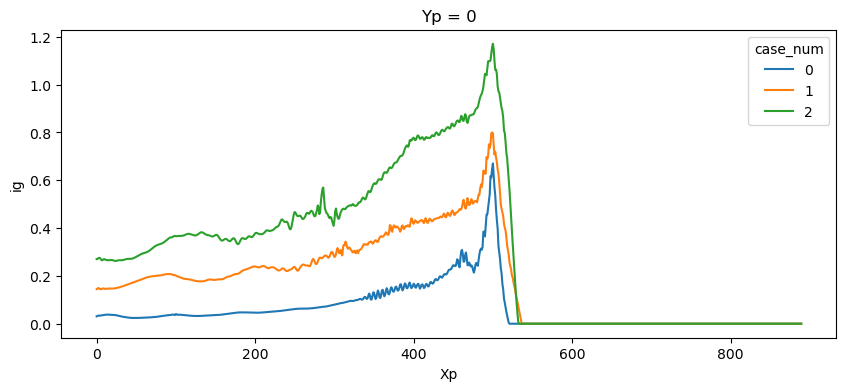

In [ ]:
postprocessed_cases.ig.plot(hue="case_num", figsize=(10, 4))